## Part I: Data Pre-processing

In [1]:
import pandas as pd

In [2]:
# Download the Google Analogy dataset
!wget http://download.tensorflow.org/data/questions-words.txt

--2025-09-28 02:56:47--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 2404:6800:4012:7::201b, 2404:6800:4012:8::201b, 2404:6800:4012:9::201b, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|2404:6800:4012:7::201b|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: 'questions-words.txt'

     0K .......... .......... .......... .......... ..........  8% 1.78M 0s
    50K .......... .......... .......... .......... .......... 16% 3.19M 0s
   100K .......... .......... .......... .......... .......... 25% 4.13M 0s
   150K .......... .......... .......... .......... .......... 33% 4.32M 0s
   200K .......... .......... .......... .......... .......... 42% 10.5M 0s
   250K .......... .......... .......... .......... .......... 50% 5.06M 0s
   300K .......... .......... .......... .......... .......... 59% 5.34M 0s
   350K .......... ........

In [3]:
# Preprocess the dataset
file_name = "questions-words"
with open(f"{file_name}.txt", "r") as f:
    data = f.read().splitlines()

In [4]:
# check data from the first 10 entries
for entry in data[:10]:
    print(entry)

: capital-common-countries
Athens Greece Baghdad Iraq
Athens Greece Bangkok Thailand
Athens Greece Beijing China
Athens Greece Berlin Germany
Athens Greece Bern Switzerland
Athens Greece Cairo Egypt
Athens Greece Canberra Australia
Athens Greece Hanoi Vietnam
Athens Greece Havana Cuba


In [ ]:
# TODO1: Write your code here for processing data to pd.DataFrame
# Please note that the first five mentions of ": " indicate `semantic`,
# and the remaining nine belong to the `syntatic` category.

# With AI support
# Process the raw data into a DataFrame.
questions = []
categories = []
sub_categories = []
header_count = 0

for line in data:
    if line.startswith(":"):
        header_count += 1
        current_category = "Semantic" if header_count <= 5 else "Syntatic"
        current_sub_category = line.strip()
    else:
        questions.append(line.strip())
        categories.append(current_category)
        sub_categories.append(current_sub_category)

print("Number of analogy questions:", len(questions))


Number of analogy questions: 19544


In [6]:
# Create the dataframe
df = pd.DataFrame(
    {
        "Question": questions,
        "Category": categories,
        "SubCategory": sub_categories,
    }
)

In [7]:
df.head()

,Question,Category,SubCategory
0,Athens Greece Baghdad Iraq,Semantic,: capital-common-countries
1,Athens Greece Bangkok Thailand,Semantic,: capital-common-countries
2,Athens Greece Beijing China,Semantic,: capital-common-countries
3,Athens Greece Berlin Germany,Semantic,: capital-common-countries
4,Athens Greece Bern Switzerland,Semantic,: capital-common-countries


In [8]:
df.to_csv(f"{file_name}.csv", index=False)

## Part II: Use pre-trained word embeddings
- After finish Part I, you can run Part II code blocks only.

In [1]:
import pandas as pd
import numpy as np
import gensim.downloader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
data = pd.read_csv("questions-words.csv")

In [3]:
MODEL_NAME = "glove-wiki-gigaword-100"
# You can try other models.
# https://radimrehurek.com/gensim/models/word2vec.html#pretrained-models

# Load the pre-trained model (using GloVe vectors here)
model = gensim.downloader.load(MODEL_NAME)
print("The Gensim model loaded successfully!")

The Gensim model loaded successfully!


In [6]:
# Do predictions and preserve the gold answers (word_D)
preds = []
golds = []

for analogy in tqdm(data["Question"]):
    # TODO2: Write your code here to use pre-trained word embeddings for getting predictions of the analogy task.
    # You should also preserve the gold answers during iterations for evaluations later.
    """ Hints
    # Unpack the analogy (e.g., "man", "woman", "king", "queen")
    # Perform vector arithmetic: word_b + word_c - word_a should be close to word_d
    # Source: https://github.com/piskvorky/gensim/blob/develop/gensim/models/keyedvectors.py#L776
    # Mikolov et al., 2013: big - biggest and small - smallest
    # Mikolov et al., 2013: X = vector(”biggest”) − vector(”big”) + vector(”small”).
    """
    # With AI support
    words = analogy.split()
    if len(words) != 4:
        preds.append(None)
        golds.append(None)
        continue
    
    word_a, word_b, word_c, word_d = words
    lower_a = word_a.lower()
    lower_b = word_b.lower()
    lower_c = word_c.lower()
    
    pred_word = None
    
    try:
        prediction_tuple = model.most_similar(positive=[lower_b, lower_c], negative=[lower_a], topn=1)
        pred_word = prediction_tuple[0][0]   
    except KeyError:
        pred_word = None
        
    golds.append(word_d)
    if pred_word is not None:
        if pred_word == word_d.lower():
            preds.append(word_d)
        else:
            preds.append(None)
    else:
        preds.append(None)
        
data["Prediction"] = preds

100%|██████████| 19544/19544 [08:24<00:00, 38.75it/s]


In [7]:
# Perform evaluations. You do not need to modify this block!!

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 65.3399481339497%
Category: Syntatic, Accuracy: 61.255269320843084%
Sub-Category: capital-common-countries, Accuracy: 93.87351778656127%
Sub-Category: capital-world, Accuracy: 88.94783377541998%
Sub-Category: currency, Accuracy: 14.203233256351039%
Sub-Category: city-in-state, Accuracy: 30.806647750304013%
Sub-Category: family, Accuracy: 81.62055335968378%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 24.39516129032258%
Sub-Category: gram2-opposite, Accuracy: 20.073891625615765%
Sub-Category: gram3-comparative, Accuracy: 79.12912912912913%
Sub-Category: gram4-superlative, Accuracy: 54.278074866310156%
Sub-Category: gram5-present-participle, Accuracy: 69.50757575757575%
Sub-Category: gram6-nationality-adjective, Accuracy: 87.86741713570981%
Sub-Category: gram7-past-tense, Accuracy: 55.44871794871795%
Sub-Category: gram8-plural, Accuracy: 71.996996996997%
Sub-Category: gram9-plural-verbs, Accuracy: 58.39080459770115%


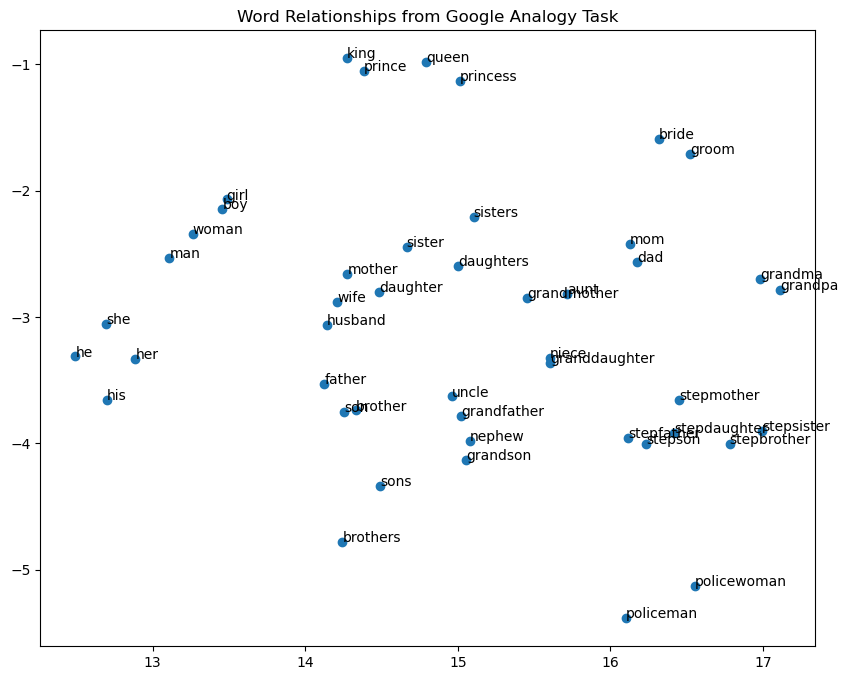

<Figure size 640x480 with 0 Axes>

In [8]:
# Collect words from Google Analogy dataset
SUB_CATEGORY = ": family"

# TODO3: Plot t-SNE for the words in the SUB_CATEGORY `: family`

# With AI support
# Filter data for sub-category ": family"
family_df = data[data["SubCategory"] == SUB_CATEGORY]
# Collect unique words from the questions
words_list = []
for question in family_df["Question"]:
    words_list.extend(question.split())
words_list = list(set(words_list))
# Retrieve word vectors from the pre-trained model
word_vectors = {}
for word in words_list:
    try:
        word_vectors[word] = model[word]
    except KeyError:
        continue

import numpy as np
from sklearn.manifold import TSNE
if len(word_vectors) > 0:
    words = list(word_vectors.keys())
    vectors = np.array(list(word_vectors.values()))
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(vectors)
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
    for i, word in enumerate(words):
         plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))
else:
    print("No words found for sub category: " + SUB_CATEGORY)

plt.title("Word Relationships from Google Analogy Task")
plt.show()
plt.savefig("word_relationships.png", bbox_inches="tight")

### Part III: Train your own word embeddings

### Get the latest English Wikipedia articles and do sampling.
- Usually, we start from Wikipedia dump (https://dumps.wikimedia.org/enwiki/latest/enwiki-latest-pages-articles.xml.bz2). However, the downloading step will take very long. Also, the cleaning step for the Wikipedia corpus ([`gensim.corpora.wikicorpus.WikiCorpus`](https://radimrehurek.com/gensim/corpora/wikicorpus.html#gensim.corpora.wikicorpus.WikiCorpus)) will take much time. Therefore, we provide cleaned files for you.

In [ ]:
# Download the split Wikipedia files
# Each file contain 562365 lines (articles).
!gdown --id 1jiu9E1NalT2Y8EIuWNa1xf2Tw1f1XuGd -O wiki_texts_part_0.txt.gz
!gdown --id 1ABblLRd9HXdXvaNv8H9fFq984bhnowoG -O wiki_texts_part_1.txt.gz
!gdown --id 1z2VFNhpPvCejTP5zyejzKj5YjI_Bn42M -O wiki_texts_part_2.txt.gz
!gdown --id 1VKjded9BxADRhIoCzXy_W8uzVOTWIf0g -O wiki_texts_part_3.txt.gz
!gdown --id 16mBeG26m9LzHXdPe8UrijUIc6sHxhknz -O wiki_texts_part_4.txt.gz

In [ ]:
# Download the split Wikipedia files
# Each file contain 562365 lines (articles), except the last file.
!gdown --id 17JFvxOH-kc-VmvGkhG7p3iSZSpsWdgJI -O wiki_texts_part_5.txt.gz
!gdown --id 19IvB2vOJRGlrYulnTXlZECR8zT5v550P -O wiki_texts_part_6.txt.gz
!gdown --id 1sjwO8A2SDOKruv6-8NEq7pEIuQ50ygVV -O wiki_texts_part_7.txt.gz
!gdown --id 1s7xKWJmyk98Jbq6Fi1scrHy7fr_ellUX -O wiki_texts_part_8.txt.gz
!gdown --id 17eQXcrvY1cfpKelLbP2BhQKrljnFNykr -O wiki_texts_part_9.txt.gz
!gdown --id 1J5TAN6bNBiSgTIYiPwzmABvGhAF58h62 -O wiki_texts_part_10.txt.gz

In [ ]:
# Extract the downloaded wiki_texts_parts files.
!gunzip -k wiki_texts_part_*.gz

In [ ]:
# Combine the extracted wiki_texts_parts files.
!cat wiki_texts_part_*.txt > wiki_texts_combined.txt

In [ ]:
# Check the first ten lines of the combined file
!head -n 10 wiki_texts_combined.txt

In [ ]:
# New added
# Check the first ten lines of the combined file
filename = "wiki_texts_combined.txt"

try:
    with open(filename, "r", encoding="utf-8") as f:
        print(f"--- Displaying first 10 lines of {filename} ---")
        for i, line in enumerate(f):
            if i >= 10:
                break
            print(line, end="")
            
except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")

--- Displaying first 10 lines of wiki_texts_combined.txt ---
﻿anarchism is political philosophy and movement that is against all forms of authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy typically including the state and capitalism anarchism advocates for the replacement of the state with stateless societies and voluntary free associations as historically left wing movement this reading of anarchism is placed on the farthest left of the political spectrum usually described as the libertarian wing of the socialist movement libertarian socialism although traces of anarchist ideas are found all throughout history modern anarchism emerged from the enlightenment during the latter half of the th and the first decades of the th century the anarchist movement flourished in most parts of the world and had significant role in workers struggles for emancipation various anarchist schools of thought formed during this period anarchists have taken

Please note that we used the default parameters of [`gensim.corpora.wikicorpus.WikiCorpus`](https://radimrehurek.com/gensim/corpora/wikicorpus.html#gensim.corpora.wikicorpus.WikiCorpus) for cleaning the Wiki raw file. Thus, words with one character were discarded.

In [17]:
# Now you need to do sampling because the corpus is too big.
# You can further perform analysis with a greater sampling ratio.

import random

wiki_txt_path = "wiki_texts_combined.txt"
output_path = "wiki_texts_sampled.txt"
# wiki_texts_combined.txt is a text file separated by linebreaks (\n).
# Each row in wiki_texts_combined.txt indicates a Wikipedia article.

with open(wiki_txt_path, "r", encoding="utf-8") as f:
    with open(output_path, "w", encoding="utf-8") as output_file:
    # TODO4: Sample `20%` Wikipedia articles
    # Write your code here

        # With AI support
        for line in f:
            # This condition will be true for approximately 20% of the lines.
            if random.random() < 0.1:
                output_file.write(line)

In [ ]:
# TODO5: Train your own word embeddings with the sampled articles
# https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Word2Vec
# Hint: You should perform some pre-processing before training.

# With AI support
import re
from gensim.models import Word2Vec

def tokenize(text):
    text = text.strip().lower()
    # Remove non-alphanumeric chars (except for whitespace)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

# Define an iterator class to stream the file
class SentenceIterator:
    def __init__(self, filepath):
        self.filepath = filepath

    def __iter__(self):
        with open(self.filepath, "r", encoding="utf-8") as f:
            for line in f:
                # process and yield one line at a time
                if line.strip() != "":
                    yield tokenize(line)

wiki_txt_path = "wiki_texts_sampled.txt"

# 1. Create an instance of our iterator.
#    This does NOT load the file into memory.
sentences = SentenceIterator(wiki_txt_path)

# 2. Pass the iterator directly to Word2Vec.
#    The model will pull sentences from the iterator one by one.
print("Training custom Word2Vec model (this will take time)...")
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4, sg=1)
print("Trained custom Word2Vec model.")

# Optionally, save the model for future use.
w2v_model.save("custom_w2v.model")

Training custom Word2Vec model (this will take time)...


In [ ]:
data = pd.read_csv("questions-words.csv")

In [ ]:
# New added
from gensim.models import Word2Vec
model_path = "custom_w2v.model"
w2v_model = Word2Vec.load(model_path)
print("Custom Word2Vec model loaded successfully!")

Custom Word2Vec model loaded successfully!


In [ ]:
# Do predictions and preserve the gold answers (word_D)
preds = []
golds = []

for analogy in tqdm(data["Question"]):
      # TODO6: Write your code here to use your trained word embeddings for getting predictions of the analogy task.
      # You should also preserve the gold answers during iterations for evaluations later.
    """ Hints
    # Unpack the analogy (e.g., "man", "woman", "king", "queen")
    # Perform vector arithmetic: word_b + word_c - word_a should be close to word_d
    # Source: https://github.com/piskvorky/gensim/blob/develop/gensim/models/keyedvectors.py#L776
    # Mikolov et al., 2013: big - biggest and small - smallest
    # Mikolov et al., 2013: X = vector(”biggest”) − vector(”big”) + vector(”small”).
    """
    # With AI support
    words = analogy.split()
    if len(words) != 4:
        preds.append(None)
        golds.append(None)
        continue
    
    word_a, word_b, word_c, word_d = words
    lower_a = word_a.lower()
    lower_b = word_b.lower()
    lower_c = word_c.lower()
    
    pred_word = None
    
    try:
        prediction_tuple = w2v_model.wv.most_similar(positive=[lower_b, lower_c], negative=[lower_a], topn=1)
        pred_word = prediction_tuple[0][0]   
    except KeyError:
        pred_word = None
        
    golds.append(word_d)
    if pred_word is not None:
        if pred_word == word_d.lower():
            preds.append(word_d)
        else:
            preds.append(None)
    else:
        preds.append(None)
        
data["Prediction"] = preds

100%|██████████| 19544/19544 [09:31<00:00, 34.21it/s]


In [ ]:
# New Added
# Perform evaluations. You do not need to modify this block!!

def calculate_accuracy(gold: np.ndarray, pred: np.ndarray) -> float:
    return np.mean(gold == pred)

golds_np, preds_np = np.array(golds), np.array(preds)
data = pd.read_csv("questions-words.csv")

# Evaluation: categories
for category in data["Category"].unique():
    mask = data["Category"] == category
    golds_cat, preds_cat = golds_np[mask], preds_np[mask]
    acc_cat = calculate_accuracy(golds_cat, preds_cat)
    print(f"Category: {category}, Accuracy: {acc_cat * 100}%")

# Evaluation: sub-categories
for sub_category in data["SubCategory"].unique():
    mask = data["SubCategory"] == sub_category
    golds_subcat, preds_subcat = golds_np[mask], preds_np[mask]
    acc_subcat = calculate_accuracy(golds_subcat, preds_subcat)
    print(f"Sub-Category{sub_category}, Accuracy: {acc_subcat * 100}%")

Category: Semantic, Accuracy: 58.946893674596915%
Category: Syntatic, Accuracy: 40.131147540983605%
Sub-Category: capital-common-countries, Accuracy: 88.3399209486166%
Sub-Category: capital-world, Accuracy: 74.55791335101681%
Sub-Category: currency, Accuracy: 4.503464203233257%
Sub-Category: city-in-state, Accuracy: 40.57559789217674%
Sub-Category: family, Accuracy: 72.72727272727273%
Sub-Category: gram1-adjective-to-adverb, Accuracy: 13.306451612903224%
Sub-Category: gram2-opposite, Accuracy: 10.467980295566502%
Sub-Category: gram3-comparative, Accuracy: 46.246246246246244%
Sub-Category: gram4-superlative, Accuracy: 18.983957219251337%
Sub-Category: gram5-present-participle, Accuracy: 33.996212121212125%
Sub-Category: gram6-nationality-adjective, Accuracy: 86.92933083176986%
Sub-Category: gram7-past-tense, Accuracy: 36.666666666666664%
Sub-Category: gram8-plural, Accuracy: 44.069069069069066%
Sub-Category: gram9-plural-verbs, Accuracy: 37.93103448275862%


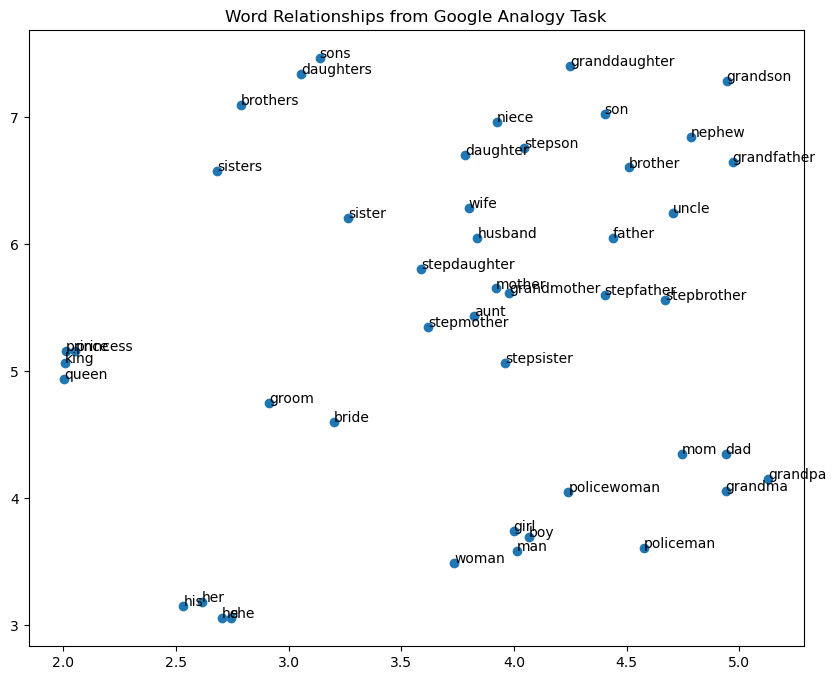

<Figure size 640x480 with 0 Axes>

In [ ]:
# Collect words from Google Analogy dataset
SUB_CATEGORY = ": family"

# TODO7: Plot t-SNE for the words in the SUB_CATEGORY `: family`

# Filter data for sub-category ": family"
family_df = data[data["SubCategory"] == SUB_CATEGORY]
# Collect unique words from the questions
words_list = []
for question in family_df["Question"]:
    words_list.extend(question.split())
words_list = list(set(words_list))
# Retrieve word vectors from the pre-trained model
word_vectors = {}
for word in words_list:
    try:
        word_vectors[word] = w2v_model.wv[word]
    except KeyError:
        continue

import numpy as np
from sklearn.manifold import TSNE
if len(word_vectors) > 0:
    words = list(word_vectors.keys())
    vectors = np.array(list(word_vectors.values()))
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(vectors)
    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
    for i, word in enumerate(words):
         plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))
else:
    print("No words found for sub category: " + SUB_CATEGORY)

plt.title("Word Relationships from Google Analogy Task")
plt.show()
plt.savefig("word_relationships_wiki.png", bbox_inches="tight")

In [ ]:
# New added
# Retrieving the five most similar words and presenting the results

MODEL_NAME = "glove-wiki-gigaword-100"
model = gensim.downloader.load(MODEL_NAME)
print("The Gensim model loaded successfully!")

from gensim.models import Word2Vec
model_path = "custom_w2v.model"
w2v_model = Word2Vec.load(model_path)
print("Custom Word2Vec model loaded successfully!")

import pandas as pd
# --- 1. Select a few words to test ---
# We'll choose a diverse set: a concrete noun, a proper noun, an abstract concept, and a verb.
words_to_check = ['king', 'germany', 'science', 'running']
# --- 2. Retrieve the most similar words from both models ---
results = []
for word in words_to_check:
    try:
        # Get similar words from the pre-trained GloVe model
        similar_glove = model.most_similar(word, topn=5)
        glove_words = [item[0] for item in similar_glove]

        # Get similar words from your custom-trained Word2Vec model
        # Note: we use the '.wv' attribute for the custom model's keyed vectors
        similar_custom = w2v_model.wv.most_similar(word, topn=5)
        custom_words = [item[0] for item in similar_custom]

        results.append({
            'Query Word': word,
            'Similar from GloVe (Pre-trained)': ", ".join(glove_words),
            'Similar from Word2Vec (Custom)': ", ".join(custom_words)
        })
    except KeyError:
        print(f"'{word}' not found in one of the model vocabularies. Skipping.")

# --- 3. Present the results in a DataFrame for easy comparison ---
if results:
    df_similar = pd.DataFrame(results)
    print("--- Top 5 Most Similar Words ---")
    display(df_similar)

The Gensim model loaded successfully!
Custom Word2Vec model loaded successfully!
--- Top 5 Most Similar Words ---


,Query Word,Similar from GloVe (Pre-trained),Similar from Word2Vec (Custom)
0,king,"prince, queen, son, brother, monarch","prince, vajiravudh, throne, nangklao, queen"
1,germany,"austria, switzerland, german, europe, poland","austria, switzerland, anschluss, gdr, berlin"
2,science,"sciences, physics, institute, mathematics, stu...","sciences, physics, humanities, economics, kaust"
3,running,"ran, run, line, going, along","raybestos, kranefuss, retzlaff, sawalich, prim..."
